开始加载数据...
特征维度: (132, 3), 目标维度: (132, 5)
使用设备: cuda

===== 训练原始模型 (ReGLU) =====
Epoch 50/300, Train RMSE: 0.2489, Val RMSE: 0.2882
Epoch 100/300, Train RMSE: 0.1557, Val RMSE: 0.1091
Epoch 150/300, Train RMSE: 0.1236, Val RMSE: 0.0841
Epoch 200/300, Train RMSE: 0.1327, Val RMSE: 0.0753
Epoch 250/300, Train RMSE: 0.1120, Val RMSE: 0.0690
Epoch 300/300, Train RMSE: 0.1174, Val RMSE: 0.0656

===== 训练消融模型 (ReLU) =====
Epoch 50/300, Train RMSE: 0.3576, Val RMSE: 0.1700
Epoch 100/300, Train RMSE: 0.2567, Val RMSE: 0.1883
Epoch 150/300, Train RMSE: 0.1654, Val RMSE: 0.1328
Epoch 200/300, Train RMSE: 0.1531, Val RMSE: 0.1282
Epoch 250/300, Train RMSE: 0.1557, Val RMSE: 0.1062
Epoch 300/300, Train RMSE: 0.1418, Val RMSE: 0.1066

===== 测试集评估对比 =====

原始模型 (ReGLU):
  总体: MSE=0.001082, RMSE=0.032889, MAE=0.018407, R2=0.988568
  CL: RMSE=0.043143, R2=0.987731, MRE=5.7372%
  CD: RMSE=0.032681, R2=0.993819, MRE=16.1251%
  CN: RMSE=0.049260, R2=0.990624, MRE=4.9759%
  CA: RMSE=0.003334, R2=0.980945, M

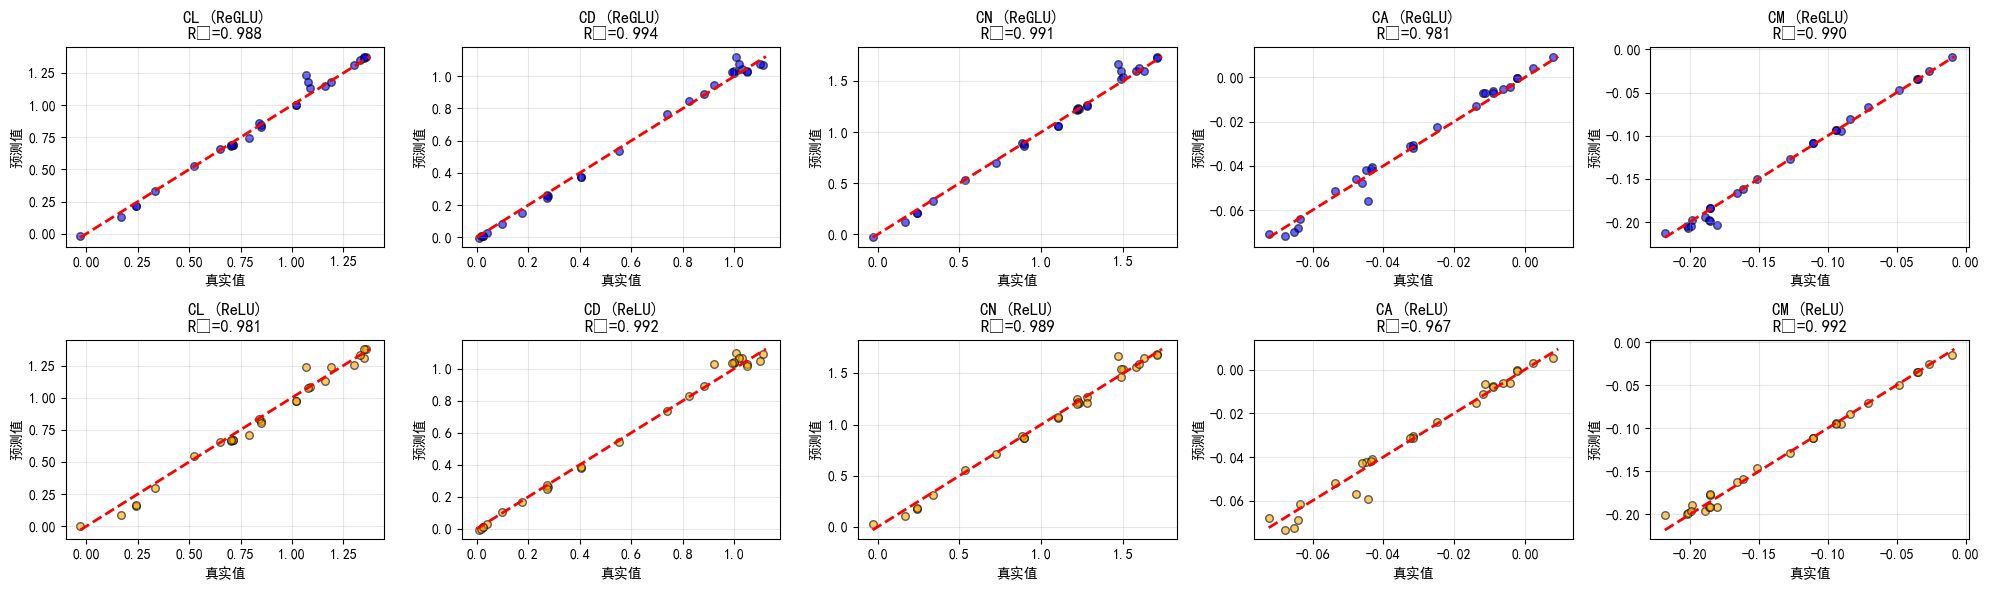

对比图已保存至 ablation_reglu_vs_relu.png

消融实验完成！


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

# ==================== 参数定义 ====================
epochs = 300
batch_size = 64
learning_rate = 0.001
weight_decay = 0.0001

# ==================== 数据加载与预处理 ====================
print("开始加载数据...")
df = pd.read_excel('data_all.xlsx')
feature_columns = ['MA', 'BETA', 'AA']
target_columns = ['CL', 'CD', 'CN', 'CA', 'CM']
X = df[feature_columns].values
y = df[target_columns].values
print(f"特征维度: {X.shape}, 目标维度: {y.shape}")

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

# 转换为 Tensor
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==================== 模型定义 ====================
class NumericalFeatureTokenizer(nn.Module):
    def __init__(self, num_features, d_model):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(num_features, d_model))
        self.bias = nn.Parameter(torch.randn(num_features, d_model))
    def forward(self, x):
        x = x.unsqueeze(-1)
        x = x * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)
        return x

# 原始 FT-Transformer 层（使用 ReGLU）
class TransformerEncoderLayer_ReGLU(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward * 2)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.act = lambda x: x.chunk(2, dim=-1)[0] * nn.functional.relu(x.chunk(2, dim=-1)[1])  # ReGLU
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, src):
        src2 = self.self_attn(src, src, src)[0]
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.act(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

# 消融变体：使用标准 ReLU
class TransformerEncoderLayer_ReLU(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.act = nn.ReLU()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, src):
        src2 = self.self_attn(src, src, src)[0]
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.act(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

# 通用 FTTransformer 构建器
def build_ft_transformer(encoder_layer_class, num_features, num_outputs, d_model=128, nhead=8, num_layers=6, dim_feedforward=512, dropout=0.1):
    class FTTransformer(nn.Module):
        def __init__(self):
            super().__init__()
            self.numerical_tokenizer = NumericalFeatureTokenizer(num_features, d_model)
            self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
            self.pos_embedding = nn.Parameter(torch.randn(1, num_features + 1, d_model))
            self.dropout_layer = nn.Dropout(dropout)
            self.transformer_layers = nn.ModuleList([
                encoder_layer_class(d_model, nhead, dim_feedforward, dropout)
                for _ in range(num_layers)
            ])
            self.output_head = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, num_outputs)
            )
            self.linear_shortcut = nn.Linear(num_features, num_outputs)
            self._init_weights()
        def _init_weights(self):
            for p in self.parameters():
                if p.dim() > 1:
                    nn.init.xavier_uniform_(p)
            nn.init.constant_(self.linear_shortcut.weight, 0.0)
            nn.init.constant_(self.linear_shortcut.bias, 0.0)
        def forward(self, x):
            batch_size = x.size(0)
            res_linear = self.linear_shortcut(x)
            numerical_tokens = self.numerical_tokenizer(x)
            cls_tokens = self.cls_token.expand(batch_size, -1, -1)
            x_deep = torch.cat([cls_tokens, numerical_tokens], dim=1)
            x_deep = x_deep + self.pos_embedding
            x_deep = self.dropout_layer(x_deep)
            for layer in self.transformer_layers:
                x_deep = layer(x_deep)
            cls_output = x_deep[:, 0, :]
            res_deep = self.output_head(cls_output)
            return res_deep + res_linear
    return FTTransformer()

# ==================== 损失函数与训练 ====================
def combined_loss(y_true, y_pred):
    mse = nn.MSELoss()(y_true, y_pred)
    mae = nn.L1Loss()(y_true, y_pred)
    return mse + 0.33 * mae

def train_model(model, train_loader, val_loader, device, epochs=epochs, lr=learning_rate, wd=weight_decay):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-8, verbose=False)
    best_val_rmse = float('inf')
    patience_counter = 0
    patience = 3000  # 实际上不会触发，只用于早停演示
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_rmse = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = combined_loss(batch_y, y_pred)
            mse = nn.MSELoss()(y_pred, batch_y)
            rmse = torch.sqrt(mse)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            train_rmse += rmse.item()
        train_loss /= len(train_loader)
        train_rmse /= len(train_loader)
        
        model.eval()
        val_loss = 0.0
        val_rmse = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = combined_loss(batch_y, outputs)
                mse = nn.MSELoss()(outputs, batch_y)
                rmse = torch.sqrt(mse)
                val_loss += loss.item()
                val_rmse += rmse.item()
        val_loss /= len(val_loader)
        val_rmse /= len(val_loader)
        
        scheduler.step(val_rmse)
        
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            torch.save(model.state_dict(), 'best_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            print(f'Epoch {epoch+1} early stopping')
            break
        if (epoch+1) % 50 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Train RMSE: {train_rmse:.4f}, Val RMSE: {val_rmse:.4f}')
    
    model.load_state_dict(torch.load('best_model.pth'))
    return model

def evaluate_model(model, data_loader, scaler_y, device):
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            all_preds.append(outputs.cpu().numpy())
            all_trues.append(batch_y.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_trues = np.vstack(all_trues)
    all_preds_orig = scaler_y.inverse_transform(all_preds)
    all_trues_orig = scaler_y.inverse_transform(all_trues)
    
    total_mse = mean_squared_error(all_trues_orig, all_preds_orig)
    total_rmse = np.sqrt(total_mse)
    total_mae = mean_absolute_error(all_trues_orig, all_preds_orig)
    total_r2 = r2_score(all_trues_orig, all_preds_orig)
    mse_loss = np.mean((all_trues_orig - all_preds_orig) ** 2)
    mae_loss = np.mean(np.abs(all_trues_orig - all_preds_orig))
    total_combined = mse_loss
    
    n_outputs = all_trues_orig.shape[1]
    component_metrics = {}
    for i in range(n_outputs):
        y_true_i = all_trues_orig[:, i]
        y_pred_i = all_preds_orig[:, i]
        rmse_i = np.sqrt(mean_squared_error(y_true_i, y_pred_i))
        mae_i = mean_absolute_error(y_true_i, y_pred_i)
        r2_i = r2_score(y_true_i, y_pred_i)
        epsilon = 1e-8
        mre_i = np.mean(np.abs((y_true_i - y_pred_i) / (np.abs(y_true_i) + epsilon)))
        component_metrics[i] = {'RMSE': rmse_i, 'MAE': mae_i, 'R2': r2_i, 'MRE': mre_i}
    
    overall_metrics = {
        'MSE': total_mse, 'RMSE': total_rmse, 'MAE': total_mae,
        'R2': total_r2, 'Combined_Loss': total_combined
    }
    return overall_metrics, component_metrics, (all_trues_orig, all_preds_orig)

# ==================== 主实验：分别训练两个模型 ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 1. 原始模型（ReGLU）
print("\n===== 训练原始模型 (ReGLU) =====")
model_reglu = build_ft_transformer(
    encoder_layer_class=TransformerEncoderLayer_ReGLU,
    num_features=X_train.shape[1], num_outputs=5,
    d_model=128, nhead=8, num_layers=6, dim_feedforward=512, dropout=0.1
).to(device)
model_reglu = train_model(model_reglu, train_loader, val_loader, device)

# 2. 消融模型（ReLU）
print("\n===== 训练消融模型 (ReLU) =====")
model_relu = build_ft_transformer(
    encoder_layer_class=TransformerEncoderLayer_ReLU,
    num_features=X_train.shape[1], num_outputs=5,
    d_model=128, nhead=8, num_layers=6, dim_feedforward=512, dropout=0.1
).to(device)
model_relu = train_model(model_relu, train_loader, val_loader, device)

# ==================== 评估对比 ====================
print("\n===== 测试集评估对比 =====")
reglu_overall, reglu_comp, (reglu_true, reglu_pred) = evaluate_model(model_reglu, test_loader, scaler_y, device)
relu_overall, relu_comp, (relu_true, relu_pred) = evaluate_model(model_relu, test_loader, scaler_y, device)

print("\n原始模型 (ReGLU):")
print(f"  总体: MSE={reglu_overall['MSE']:.6f}, RMSE={reglu_overall['RMSE']:.6f}, MAE={reglu_overall['MAE']:.6f}, R2={reglu_overall['R2']:.6f}")
for i, name in enumerate(target_columns):
    print(f"  {name}: RMSE={reglu_comp[i]['RMSE']:.6f}, R2={reglu_comp[i]['R2']:.6f}, MRE={reglu_comp[i]['MRE']:.4%}")

print("\n消融模型 (ReLU):")
print(f"  总体: MSE={relu_overall['MSE']:.6f}, RMSE={relu_overall['RMSE']:.6f}, MAE={relu_overall['MAE']:.6f}, R2={relu_overall['R2']:.6f}")
for i, name in enumerate(target_columns):
    print(f"  {name}: RMSE={relu_comp[i]['RMSE']:.6f}, R2={relu_comp[i]['R2']:.6f}, MRE={relu_comp[i]['MRE']:.4%}")

# ==================== 可视化对比 ====================
def plot_comparison(true1, pred1, true2, pred2, target_names, comp1, comp2, save_path='ablation_reglu_vs_relu.png'):
    n = len(target_names)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)
    for i, name in enumerate(target_names):
        # 第一行：ReGLU
        ax = axes[0, i]
        ax.scatter(true1[:, i], pred1[:, i], alpha=0.6, edgecolors='k', s=30, color='blue')
        min_val = min(true1[:, i].min(), pred1[:, i].min())
        max_val = max(true1[:, i].max(), pred1[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        ax.set_xlabel('真实值')
        ax.set_ylabel('预测值')
        ax.set_title(f'{name} (ReGLU)\nR²={comp1[i]["R2"]:.3f}')
        ax.grid(True, alpha=0.3)
        # 第二行：ReLU
        ax = axes[1, i]
        ax.scatter(true2[:, i], pred2[:, i], alpha=0.6, edgecolors='k', s=30, color='orange')
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        ax.set_xlabel('真实值')
        ax.set_ylabel('预测值')
        ax.set_title(f'{name} (ReLU)\nR²={comp2[i]["R2"]:.3f}')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"对比图已保存至 {save_path}")

plot_comparison(reglu_true, reglu_pred, relu_true, relu_pred, target_columns, reglu_comp, relu_comp)

print("\n消融实验完成！")